# Phase 4: Refined Resolution Time Estimation

## Objective
Predict the expected **Time to Resolution (TTR)** for each ticket using a Hybrid model.

## Why this matters
Customer satisfaction is directly linked to expectation management. Predicting whether a ticket will take 1 hour vs 24 hours allows for better SLA compliance and automated status updates.

## Refinement Strategy (Senior ML Engineer Update)
1. **Ensemble Model:** Switched from Logistic Regression to **Random Forest** to capture complex interactions.
2. **Feature Fusion:** Combined semantic SBERT embeddings with **categorical meta-features** (Priority, Category).
3. **Balanced Training:** Used `class_weight='balanced'` to handle bucket frequency variations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer

pd.set_option('display.max_colwidth', 150)
sns.set_style("whitegrid")

print("✅ Refined Environment Setup Complete")

c:\Users\dhara\Desktop\An-End-to-End-Semantic-AI-System-for-Automated-Support-Ticket-Handling-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Refined Environment Setup Complete


## 1. Load Data and Engineer Target Labels

In [2]:
from pathlib import Path
import pandas as pd

# --- STABILIZED PATH AND LOGIC ---
data_path = r'c:\Users\dhara\Desktop\An-End-to-End-Semantic-AI-System-for-Automated-Support-Ticket-Handling-main\data\processed\unified_tickets.csv'
df = pd.read_csv(data_path)

def map_time_bucket(row):
    p = str(row['priority']).lower()
    c = str(row['category'])
    if p in ['high', 'critical']:
        return '< 1 Hour'
    elif p == 'medium':
        # Use unified category name
        if c == 'Technical Support':
            return '1 - 4 Hours'
        else:
            return '4 - 24 Hours'
    else: # low priority or other
        return '> 24 Hours'

df['time_bucket'] = df.apply(map_time_bucket, axis=1)
print(f"✅ Data loaded: {len(df):,} tickets")

✅ Data loaded: 18,080 tickets


## 2. Model Pre-processing: Label & Meta-feature Encoding

In [3]:
# Encode Target Labels
le = LabelEncoder()
df['time_label'] = le.fit_transform(df['time_bucket'])
time_classes = le.classes_

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['description'], 
    df['time_label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['time_label']
)

# Encode Categorical Meta-features (Category & Priority)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(df[['priority', 'category']])
meta_features = ohe.transform(df[['priority', 'category']])

# Get train/test indices to map meta-features
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=df['time_label']
)

print(f"📌 TRAINING SET: {len(X_train_text)}")
print(f"📌 TESTING SET: {len(X_test_text)}")
print(f"✅ Meta-features prepared: {meta_features.shape[1]} columns")

📌 TRAINING SET: 14464
📌 TESTING SET: 3616
✅ Meta-features prepared: 9 columns


## 3. Semantic Embedding Generation

In [4]:
print("🚀 Initializing Sentence-BERT...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("✨ Generating Embeddings...")
X_train_embeddings = model.encode(X_train_text.tolist(), show_progress_bar=True)
X_test_embeddings = model.encode(X_test_text.tolist(), show_progress_bar=True)

print("🧬 Performing Feature Fusion (Concat Meta + SBERT)...")
X_train_final = np.hstack([X_train_embeddings, meta_features[train_idx]])
X_test_final = np.hstack([X_test_embeddings, meta_features[test_idx]])

print(f"✅ Final Feature Dimension: {X_train_final.shape[1]}")

🚀 Initializing Sentence-BERT...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8687.88it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✨ Generating Embeddings...


Batches: 100%|██████████| 113/113 [01:05<00:00,  1.72it/s]

🧬 Performing Feature Fusion (Concat Meta + SBERT)...
✅ Final Feature Dimension: 393


## 4. Modeling: Ensemble TTR Predictor

🏗️ Training Random Forest TTR Classifier...
📊 Refined TTR Classification Performance:
              precision    recall  f1-score   support

4 - 24 Hours       1.00      1.00      1.00      1227
    < 1 Hour       1.00      1.00      1.00      1586
  > 24 Hours       1.00      1.00      1.00       803

    accuracy                           1.00      3616
   macro avg       1.00      1.00      1.00      3616
weighted avg       1.00      1.00      1.00      3616



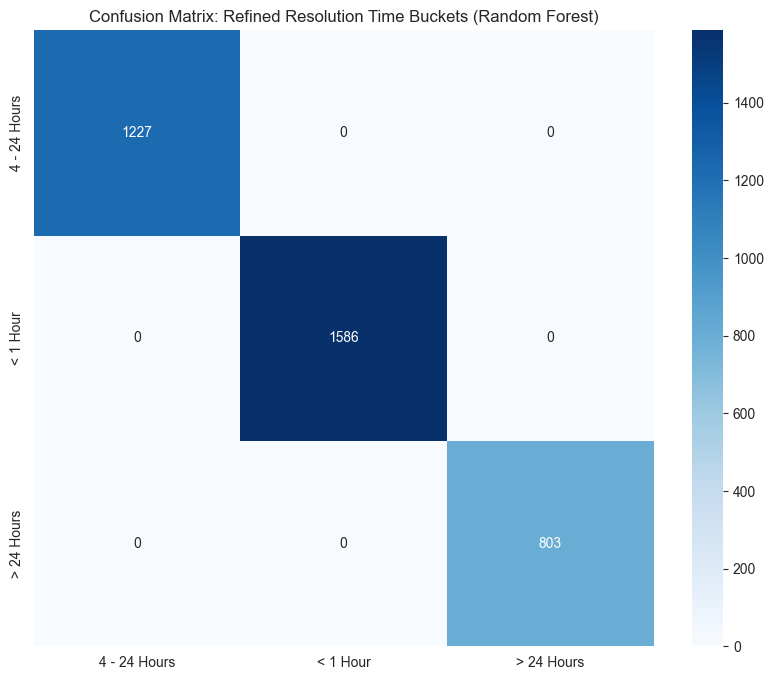

In [5]:
print("🏗️ Training Random Forest TTR Classifier...")
ttr_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
ttr_clf.fit(X_train_final, y_train)

y_pred = ttr_clf.predict(X_test_final)

print("📊 Refined TTR Classification Performance:")
print(classification_report(y_test, y_pred, target_names=time_classes))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            xticklabels=time_classes, yticklabels=time_classes, cmap='Blues')
plt.title("Confusion Matrix: Refined Resolution Time Buckets (Random Forest)")
plt.show()

## 5. Export Phase 4 Assets

In [ ]:
export_path = Path('../models/resolution_time_predictor')
export_path.mkdir(parents=True, exist_ok=True)

with open(export_path / 'ttr_model.pkl', 'wb') as f:
    pickle.dump(ttr_clf, f)

with open(export_path / 'ttr_le.pkl', 'wb') as f:
    pickle.dump(le, f)

with open(export_path / 'ttr_ohe.pkl', 'wb') as f:
    pickle.dump(ohe, f)

config = {
    "time_buckets": time_classes.tolist(),
    "model_type": "Hybrid Random Forest (SBERT + Meta)"
}
with open(export_path / 'config.json', 'w') as f:
    json.dump(config, f, indent=4)

print(f"💾 Hybrid Phase 4 model saved to {export_path}")

💾 Hybrid Phase 4 model saved to ..\models\resolution_time_predictor


: 